In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)
from sklearn.svm import LinearSVC
from pathlib import Path
import joblib

In [165]:
df = pd.read_csv("../data/intent_emails_5000.csv")
df.head()

,email_id,subject,text,label
0,1502,Job Application,Please find my resume attached for your consid...,job_career
1,2587,Schedule Update,I would like to arrange a meeting to discuss t...,meetings
2,2654,Schedule Update,The team meeting has been scheduled for Monday...,meetings
3,1056,Weekend Plans,I hope you are doing well. Let me know when we...,personal
4,706,Order Issue,The service is not working properly. Please ch...,customer_support


In [166]:
print("Dataset Shape:", df.shape)

Dataset Shape: (5000, 4)


In [167]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   email_id  5000 non-null   int64 
 1   subject   5000 non-null   object
 2   text      5000 non-null   object
 3   label     5000 non-null   object
dtypes: int64(1), object(3)
memory usage: 156.4+ KB


In [168]:
df.columns

Index(['email_id', 'subject', 'text', 'label'], dtype='object')

In [169]:
df.isnull().sum()

email_id    0
subject     0
text        0
label       0
dtype: int64

In [170]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [171]:
print("Duplicate emails:", df["text"].duplicated().sum())

Duplicate emails: 4750


In [172]:
df["label"].value_counts()

label
job_career            500
meetings              500
personal              500
customer_support      500
business              500
finance               500
travel                500
events                500
newsletter_updates    500
promotions            500
Name: count, dtype: int64

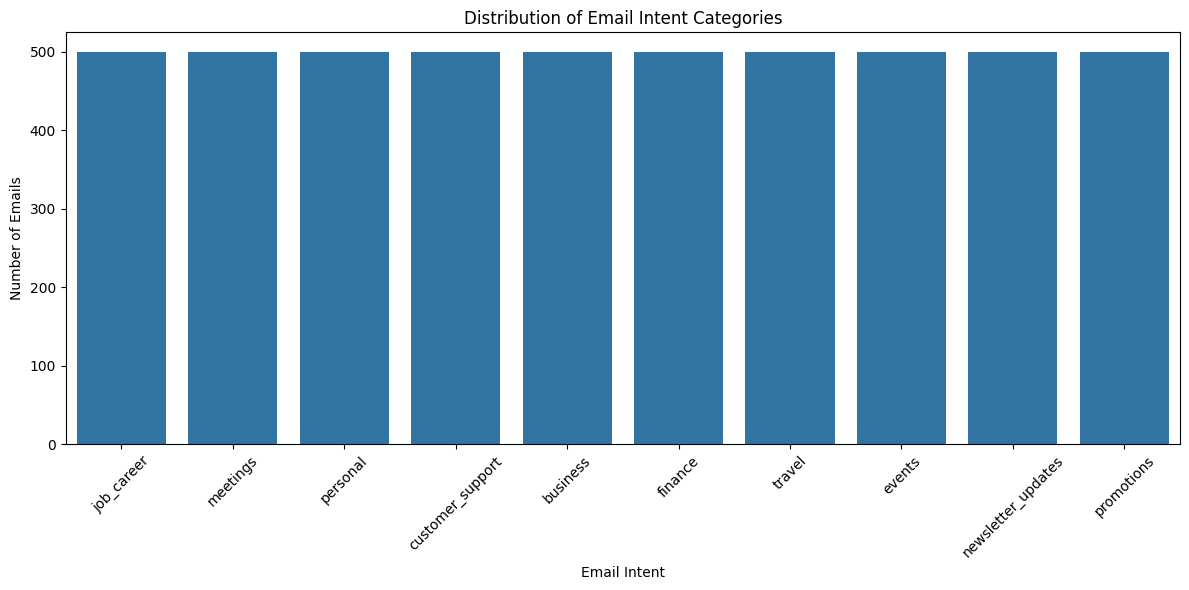

In [173]:
plt.figure(figsize=(12, 6))

sns.countplot(
    data=df,
    x="label",
    order=df["label"].value_counts().index
)

plt.title("Distribution of Email Intent Categories")
plt.xlabel("Email Intent")
plt.ylabel("Number of Emails")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [174]:
df["text_length"] = df["text"].str.len()

In [175]:
df["text_length"].describe()

count    5000.000000
mean      124.218600
std         7.631727
min       103.000000
25%       121.000000
50%       125.000000
75%       129.000000
max       140.000000
Name: text_length, dtype: float64

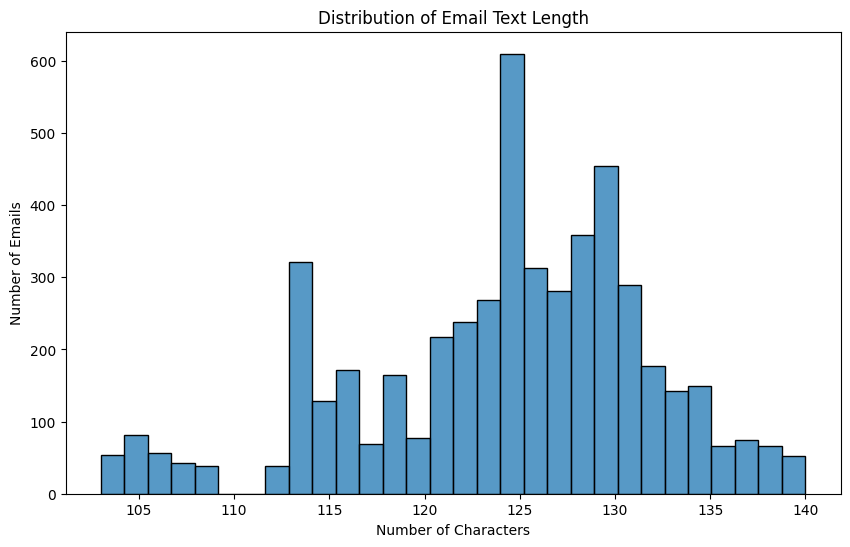

In [176]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x="text_length",
    bins=30
)

plt.title("Distribution of Email Text Length")
plt.xlabel("Number of Characters")
plt.ylabel("Number of Emails")
plt.show()

In [177]:
for category in df["label"].unique():
    print("\n" + "=" * 60)
    print("CATEGORY:", category)
    print("=" * 60)

    sample = df[df["label"] == category].sample(2, random_state=42)

    for _, row in sample.iterrows():
        print("\nSubject:", row["subject"])
        print("Email:", row["text"])


CATEGORY: job_career

Subject: Interview Invitation
Email: Please find my resume attached for your consideration. Please respond when convenient. This update is scheduled for Wednesday.

Subject: Career Opportunity
Email: I am interested in learning more about the internship opportunity. Please respond when convenient. This update is scheduled for Friday.

CATEGORY: meetings

Subject: Meeting Request
Email: Please confirm your availability for tomorrow's meeting. Please respond when convenient. This update is scheduled for Thursday.

Subject: Meeting Request
Email: Please confirm your availability for tomorrow's meeting. Please respond when convenient. This update is scheduled for Friday.

CATEGORY: personal

Subject: Checking In
Email: Please call me when you have some free time. Please respond when convenient. This update is scheduled for Thursday.

Subject: Hello
Email: I hope you are doing well. Let me know when we can catch up. Please respond when convenient. This update is sched

In [178]:
import sys
sys.path.append("../")
from src.preprocessing import preprocess_text
sample_text = """
Hello, I am interested in applying for the Software Developer
Internship. Please visit https://example.com for more information.
"""

clean_text = preprocess_text(sample_text)

print("Original:")
print(sample_text)

print("\nCleaned:")
print(clean_text)

Original:

Hello, I am interested in applying for the Software Developer
Internship. Please visit https://example.com for more information.


Cleaned:
hello interested applying software developer internship please visit information


In [179]:
df["clean_text"] = df["text"].apply(preprocess_text)

In [180]:
df[["text", "clean_text", "label"]].head(10)

,text,clean_text,label
0,Please find my resume attached for your consid...,please find resume attached consideration plea...,job_career
1,I would like to arrange a meeting to discuss t...,would like arrange meeting discus project plea...,meetings
2,The team meeting has been scheduled for Monday...,team meeting scheduled monday please respond c...,meetings
3,I hope you are doing well. Let me know when we...,hope well let know catch please respond conven...,personal
4,The service is not working properly. Please ch...,service working properly please check problem ...,customer_support
5,The client has requested an update on the proj...,client requested update project timeline pleas...,business
6,My product arrived damaged. Please help me wit...,product arrived damaged please help replacemen...,customer_support
7,Your invoice is due for payment by the end of ...,invoice due payment end month please respond c...,finance
8,Could you confirm whether my refund has been i...,could confirm whether refund issued please res...,finance
9,Could you provide an update regarding my job a...,could provide update regarding job application...,job_career


In [181]:
df["clean_length"] = df["clean_text"].str.len()

print("Average original length:",
      df["text_length"].mean())

print("Average cleaned length:",
      df["clean_length"].mean())

Average original length: 124.2186
Average cleaned length: 87.4542


In [182]:
empty_emails = (df["clean_text"].str.strip() == "").sum()

print("Empty emails after preprocessing:", empty_emails)

Empty emails after preprocessing: 0


In [183]:
X = df["clean_text"]
y = df["label"]
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [184]:
print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 4000
Testing samples: 1000


In [185]:
print("Training distribution:")
print(y_train.value_counts())

print("\nTesting distribution:")
print(y_test.value_counts())

Training distribution:
label
personal              400
meetings              400
finance               400
job_career            400
promotions            400
events                400
newsletter_updates    400
business              400
customer_support      400
travel                400
Name: count, dtype: int64

Testing distribution:
label
travel                100
newsletter_updates    100
events                100
meetings              100
finance               100
customer_support      100
personal              100
business              100
job_career            100
promotions            100
Name: count, dtype: int64


In [186]:
tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True
)

In [187]:
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)
tfidf.fit_transform(X)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 57644 stored elements and shape (5000, 395)>

In [188]:
print("Training TF-IDF shape:", X_train_tfidf.shape)
print("Testing TF-IDF shape:", X_test_tfidf.shape)

Training TF-IDF shape: (4000, 395)
Testing TF-IDF shape: (1000, 395)


In [189]:
nb_model = MultinomialNB()
nb_model.fit(X_train_tfidf, y_train)
nb_predictions = nb_model.predict(X_test_tfidf)

In [190]:
nb_accuracy = accuracy_score(y_test, nb_predictions)

print("Naive Bayes Accuracy:", nb_accuracy)
print(classification_report(y_test, nb_predictions))

Naive Bayes Accuracy: 1.0
                    precision    recall  f1-score   support

          business       1.00      1.00      1.00       100
  customer_support       1.00      1.00      1.00       100
            events       1.00      1.00      1.00       100
           finance       1.00      1.00      1.00       100
        job_career       1.00      1.00      1.00       100
          meetings       1.00      1.00      1.00       100
newsletter_updates       1.00      1.00      1.00       100
          personal       1.00      1.00      1.00       100
        promotions       1.00      1.00      1.00       100
            travel       1.00      1.00      1.00       100

          accuracy                           1.00      1000
         macro avg       1.00      1.00      1.00      1000
      weighted avg       1.00      1.00      1.00      1000



In [191]:
svm_model = LinearSVC(
    C=1.0,
    random_state=42
)
svm_model.fit(X_train_tfidf, y_train)
svm_predictions = svm_model.predict(X_test_tfidf)
svm_accuracy = accuracy_score(y_test, svm_predictions)

print("SVM Accuracy:", svm_accuracy)
print(classification_report(y_test, svm_predictions))

SVM Accuracy: 1.0
                    precision    recall  f1-score   support

          business       1.00      1.00      1.00       100
  customer_support       1.00      1.00      1.00       100
            events       1.00      1.00      1.00       100
           finance       1.00      1.00      1.00       100
        job_career       1.00      1.00      1.00       100
          meetings       1.00      1.00      1.00       100
newsletter_updates       1.00      1.00      1.00       100
          personal       1.00      1.00      1.00       100
        promotions       1.00      1.00      1.00       100
            travel       1.00      1.00      1.00       100

          accuracy                           1.00      1000
         macro avg       1.00      1.00      1.00      1000
      weighted avg       1.00      1.00      1.00      1000



In [192]:
comparison = pd.DataFrame({
    "Model": [
        "Multinomial Naive Bayes",
        "Linear SVM"
    ],
    "Accuracy": [
        nb_accuracy,
        svm_accuracy
    ]
})

comparison

,Model,Accuracy
0,Multinomial Naive Bayes,1.0
1,Linear SVM,1.0


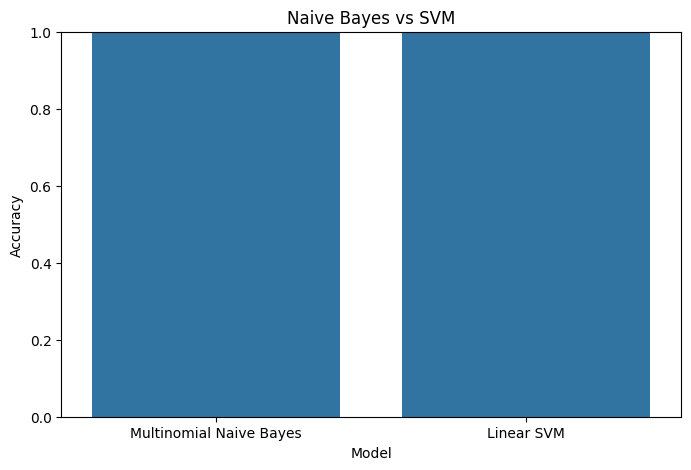

In [193]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=comparison,
    x="Model",
    y="Accuracy"
)

plt.title("Naive Bayes vs SVM")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.show()

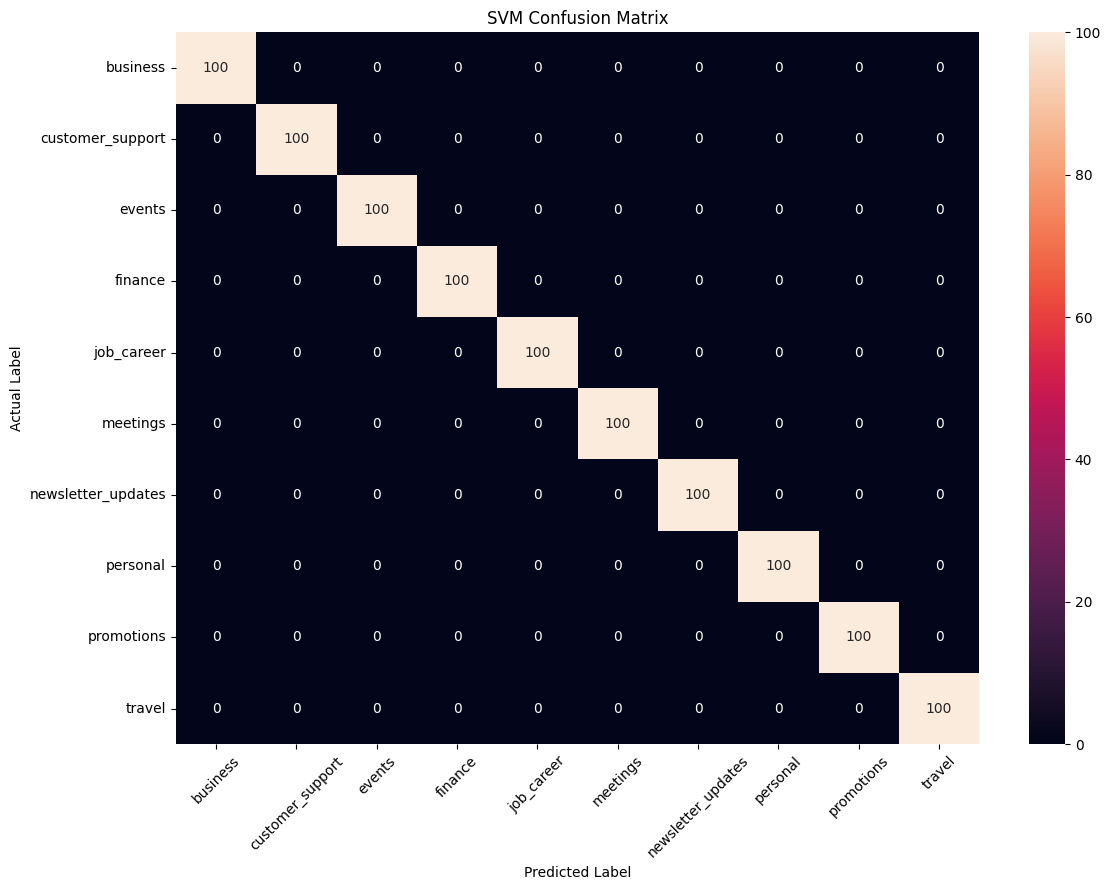

In [194]:
cm = confusion_matrix(y_test, svm_predictions)

plt.figure(figsize=(12, 9))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=sorted(y.unique()),
    yticklabels=sorted(y.unique())
)
plt.title("SVM Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [195]:
new_emails = [
    "Please send me the latest quarterly business report for review.",
    "My order has not arrived and I need help with the delivery.",
    "Can you please confirm whether my payment has been received?",
    "I would like to apply for the software engineering internship.",
    "Can we reschedule our project meeting to Friday afternoon?",
    "Please confirm my hotel reservation for next week.",
    "Would you like to come over for dinner this weekend?",
    "You are invited to attend our annual company conference.",
    "Get 50% off your next purchase with this special offer.",
    "Here are the latest updates from our monthly newsletter."
]

In [196]:
clean_new_emails = [
    preprocess_text(email)
    for email in new_emails
]
new_emails_tfidf = tfidf.transform(clean_new_emails)
nb_new_predictions = nb_model.predict(new_emails_tfidf)
svm_new_predictions = svm_model.predict(new_emails_tfidf)
for email, nb_pred, svm_pred in zip(
    new_emails,
    nb_new_predictions,
    svm_new_predictions
):
    print("=" * 70)
    print("Email:", email)
    print("Naive Bayes:", nb_pred)
    print("SVM:", svm_pred)

Email: Please send me the latest quarterly business report for review.
Naive Bayes: business
SVM: business
Email: My order has not arrived and I need help with the delivery.
Naive Bayes: customer_support
SVM: customer_support
Email: Can you please confirm whether my payment has been received?
Naive Bayes: finance
SVM: finance
Email: I would like to apply for the software engineering internship.
Naive Bayes: job_career
SVM: job_career
Email: Can we reschedule our project meeting to Friday afternoon?
Naive Bayes: meetings
SVM: meetings
Email: Please confirm my hotel reservation for next week.
Naive Bayes: travel
SVM: travel
Email: Would you like to come over for dinner this weekend?
Naive Bayes: personal
SVM: personal
Email: You are invited to attend our annual company conference.
Naive Bayes: events
SVM: events
Email: Get 50% off your next purchase with this special offer.
Naive Bayes: promotions
SVM: promotions
Email: Here are the latest updates from our monthly newsletter.
Naive Bayes

In [197]:
test_email = """
I have been charged for my order but the package has not arrived.
Please check the payment and delivery status.
"""

In [198]:
clean_test_email = preprocess_text(test_email)

test_vector = tfidf.transform([clean_test_email])

print("Naive Bayes:", nb_model.predict(test_vector)[0])
print("SVM:", svm_model.predict(test_vector)[0])

Naive Bayes: customer_support
SVM: customer_support


In [199]:
decision_scores = svm_model.decision_function(test_vector)

classes = svm_model.classes_

for category, score in zip(classes, decision_scores[0]):
    print(f"{category}: {score:.4f}")

business: -0.9929
customer_support: 0.0761
events: -1.0236
finance: -0.4650
job_career: -1.0175
meetings: -1.0482
newsletter_updates: -1.0215
personal: -0.7575
promotions: -0.6301
travel: -1.0262


In [ ]:
from pathlib import Path

models_dir = Path("../models")
models_dir.mkdir(exist_ok=True)

In [ ]:
joblib.dump(
    tfidf,
    models_dir / "intent_tfidf.joblib"
)

In [ ]:
joblib.dump(
    nb_model,
    models_dir / "intent_naive_bayes.joblib"
)

In [ ]:
joblib.dump(
    svm_model,
    models_dir / "intent_svm.joblib"
)